# Importing Libraries

In [28]:
import pandas as pd
import numpy as np

import geopandas as gpd
import folium
from folium.plugins import HeatMap
import pydeck as pdk
import hashlib



import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from shapely import wkt

# Loading DF

In [29]:
pre_norm_df_final = pd.read_csv('..\\Data\\display_rdy_ZIP_4.csv', low_memory=False)
norm_df = pd.read_csv('..\\Data\\norm_ZIP_5.csv', low_memory=False)
nyc_map = gpd.read_file("..\\Data\\Modified Zip Code Tabulation Areas (MODZCTA).geojson")



# Clustering Hierarchical

In [30]:
# Print clustering output
def output(labels):
    labels = pd.Series(labels)
    print("The labels:\n", labels)
    print("===================")
    print("Value Counts:\n", labels.value_counts())


In [31]:
# Drop incident zip column
Features = norm_df.drop("Incident_Zip", axis=1)

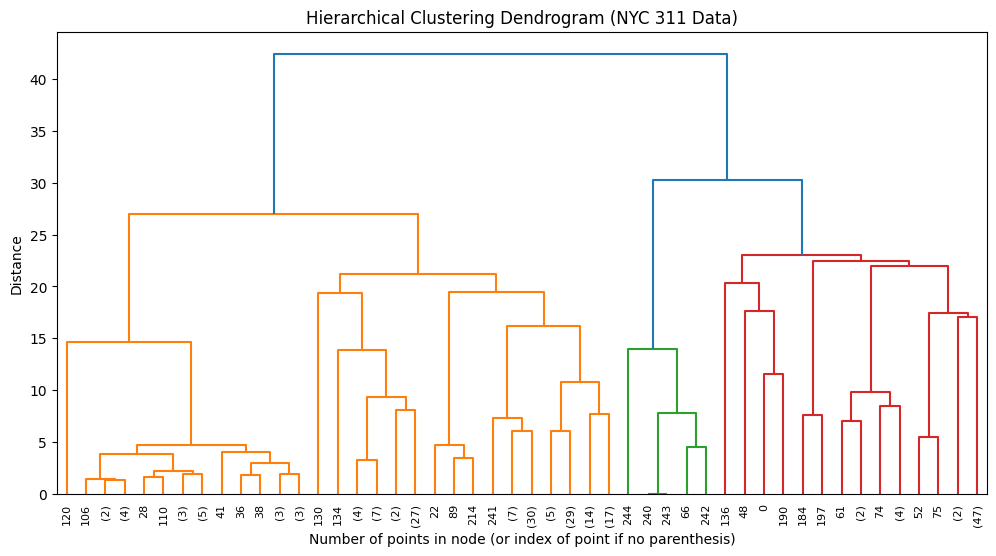

In [32]:
# Fitting the model 
agg = AgglomerativeClustering(
    distance_threshold=0,
    n_clusters=None,
    compute_distances=True
)
agg.fit(Features)

# Dendrogram plot func
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)


# Plot the Dendrogram
plt.figure(figsize=(12, 6))
plot_dendrogram(agg, truncate_mode='level', p=6) # p is rendreing limit
plt.title("Hierarchical Clustering Dendrogram (NYC 311 Data)")
plt.xlabel("Number of points in node (or index of point if no parenthesis)")
plt.ylabel("Distance")
plt.show()


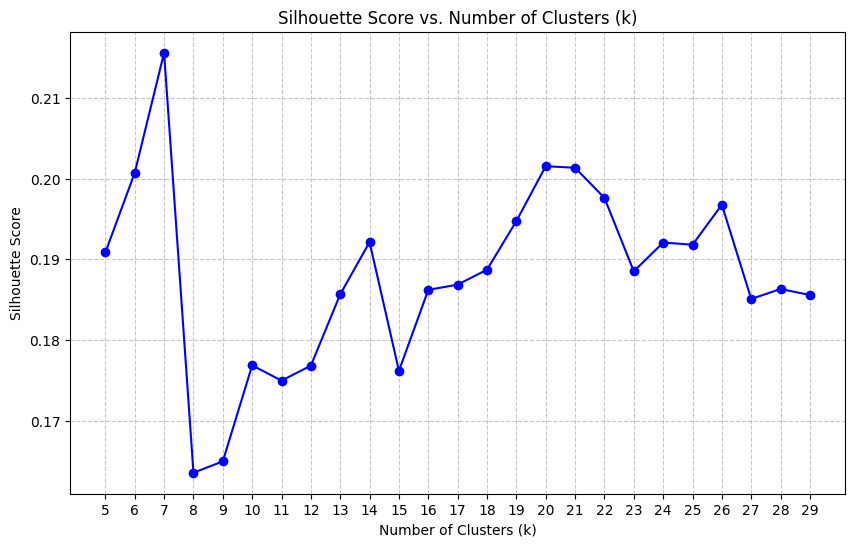

In [33]:
# Assuming 'Features' and 'pre_norm_df_final' are already defined

score_lst = []
k_range = range(5, 30) # Define the range once to keep it consistent

for k in k_range:
    # Get labels
    final_clustering = AgglomerativeClustering(n_clusters=k)
    labels = final_clustering.fit_predict(Features)
    pre_norm_df_final['Cluster'] = labels

    # Calculate the Silhouette Score
    score = silhouette_score(Features, labels)
    score_lst.append(score)

# Create the x-axis list (number of clusters)
k_lst = list(k_range)    

# --- Make the plot ---
plt.figure(figsize=(10, 6)) # Set the figure size
plt.plot(k_lst, score_lst, marker='o', linestyle='-', color='b') # Added points 'o' for visibility

# Add labels and title
plt.title('Silhouette Score vs. Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

# Formatting to make it look nice
plt.xticks(k_lst) # Shows every 'k' value on the x-axis
plt.grid(True, linestyle='--', alpha=0.7) # Adds a subtle grid

# Display the plot
plt.show()

In [ ]:
# Get labels
# K=12 is superior to k=7 as in k=7 we got 1 huge cluster and lots of outliers
final_clustering = AgglomerativeClustering(n_clusters=12)
labels = final_clustering.fit_predict(Features)
pre_norm_df_final['Cluster'] = labels
output(labels)

The labels:
 0      7
1      6
2      1
3      1
4      1
      ..
240    2
241    1
242    2
243    2
244    2
Length: 245, dtype: int64
Value Counts:
 1     103
0      51
4      41
3      27
6       8
2       5
9       3
7       2
5       2
11      1
10      1
8       1
Name: count, dtype: int64


# Draw the results on a map

In [35]:
# Define the tiny outlier clusters we want to push to the end
vc = pre_norm_df_final['Cluster'].value_counts()
outlier_clusters = singleton_labels = vc[vc == 1].index.tolist()

# Get a list of all current clusters in the dataframe, sorted numerically
current_clusters = sorted(pre_norm_df_final['Cluster'].dropna().unique())

# Separate the "main" clusters from the "outlier" clusters
main_clusters = [c for c in current_clusters if c not in outlier_clusters]
outliers_present = [c for c in outlier_clusters if c in current_clusters]

# Create a new ordered list: Main clusters first, followed by outliers at the end
new_cluster_order = main_clusters + outliers_present

# Create a mapping dictionary {old_id: new_id}
# This automatically assigns 0, 1, 2... etc.
# The main clusters will become 0 to 10, and the outliers will become 11, 12, 13, 14.
cluster_mapping = {old_id: new_id for new_id, old_id in enumerate(new_cluster_order)}

# Let's print the mapping so we can verify it worked as wanted
print("Here is how the clusters are being renumbered:")
for old, new in cluster_mapping.items():
    print(f"Old Cluster {old} --> New Cluster {new}")

# Apply the mapping to overwrite the old numbers
pre_norm_df_final['Cluster'] = pre_norm_df_final['Cluster'].map(cluster_mapping)

Here is how the clusters are being renumbered:
Old Cluster 0 --> New Cluster 0
Old Cluster 1 --> New Cluster 1
Old Cluster 2 --> New Cluster 2
Old Cluster 3 --> New Cluster 3
Old Cluster 4 --> New Cluster 4
Old Cluster 5 --> New Cluster 5
Old Cluster 6 --> New Cluster 6
Old Cluster 7 --> New Cluster 7
Old Cluster 9 --> New Cluster 8
Old Cluster 11 --> New Cluster 9
Old Cluster 10 --> New Cluster 10
Old Cluster 8 --> New Cluster 11


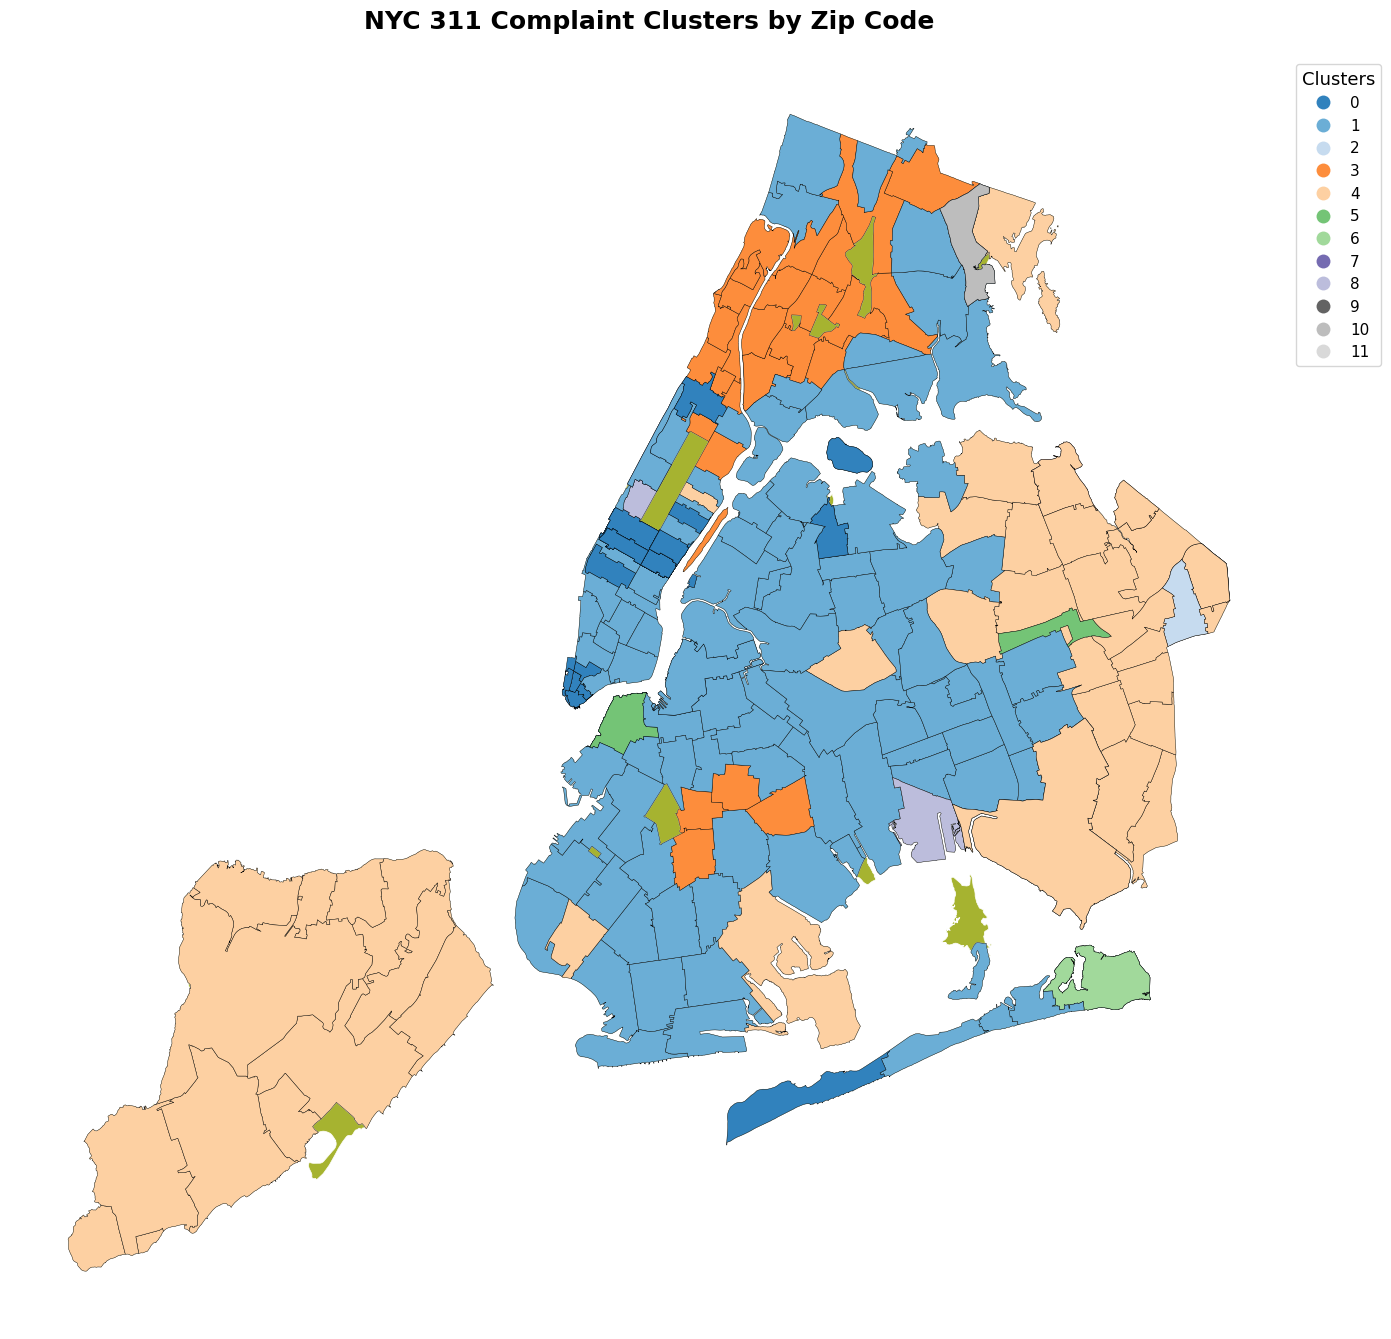

In [36]:
# Prepare the dataframe for the merge
pree_norm_df_final = pre_norm_df_final.reset_index()

# Cleaning up zip codes to remove decimals and ensure standard format
pree_norm_df_final['Incident_Zip'] = (
    pree_norm_df_final['Incident_Zip']
    .astype(str)
    .str.split('.')
    .str[0]
    .str.zfill(5)
)
nyc_map['modzcta'] = nyc_map['modzcta'].astype(str).str.strip()

# This maps point/vanity zips, airports, splits, and former "trash" zips to their parent polygons (We sused an LLM to categorize the zips)
zip_crosswalk = {
    # Midtown Manhattan Vanity Zips
    '10118': '10001', '10119': '10001', '10120': '10001', '10121': '10001', 
    '10122': '10001', '10123': '10001', '10151': '10022', '10152': '10022', 
    '10153': '10022', '10154': '10022', '10155': '10022', '10165': '10017', 
    '10166': '10017', '10167': '10017', '10168': '10017', '10169': '10017', 
    '10170': '10017', '10171': '10017', '10172': '10017', '10173': '10017', 
    '10174': '10017', '10020': '10036', '10041': '10004', '10045': '10005', 
    '10048': '10007', '10055': '10022', '10080': '10007', '10103': '10019', 
    '10105': '10019', '10106': '10019', '10107': '10019', '10110': '10036', 
    '10111': '10036', '10112': '10036', '10115': '10027', '10158': '10017', 
    '10162': '10021', '10175': '10017', '10176': '10017', '10177': '10017', 
    '10178': '10017', '10179': '10017',
    
    # Financial District / Downtown
    '10271': '10005', '10278': '10007', '10279': '10007', '10281': '10280',
    
    # Brooklyn Zips & Splits
    '11249': '11211', '11241': '11201', '11242': '11201', '11251': '11201',
    
    # Queens / Airports / Special Facilities
    '11359': '11360', # Fort Totten
    '11371': '11370', # LaGuardia Airport
    '11430': '11434', # JFK Airport
    '11695': '11691', # Far Rockaway
    '11005': '11004', # Glen Oaks border

    # --- FORMER TRASH ZIPS INCORPORATED HERE ---
    
    # Bordering Nassau & Westchester Counties (Mapped to closest NYC neighborhood)
    '10803': '10475', # Pelham Manor -> mapped to Bronx border
    '11001': '11004', # Floral Park (Nassau) -> mapped to Floral Park (Queens)
    '11021': '11363', # Great Neck -> mapped to Little Neck
    '11040': '11004', # New Hyde Park -> mapped to Floral Park (Queens)
    '11096': '11691', # Inwood (Nassau) -> mapped to Far Rockaway
    '11803': '11426', # Plainview -> mapped to Bellerose (Eastern Queens edge)

    # NYC Vanity, Parks, and Error Defaults
    '00083': '10024', # Central Park -> mapped to Upper West Side
    '10000': '10001', # Generic NYC Error -> mapped to Midtown
    '10400': '10451', # Generic Bronx Error -> mapped to South Bronx

}

# Apply crosswalk maps
pree_norm_df_final['Incident_Zip'] = pree_norm_df_final['Incident_Zip'].replace(zip_crosswalk)


# Merge the geographic polygons with the clustering labels
mapped_clusters = nyc_map.merge(
    pree_norm_df_final, 
    left_on='modzcta', 
    right_on='Incident_Zip', 
    how='inner'
)

# Plot the Choropleth Map
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

# Plot a light grey base map of ALL NYC zip codes behind the data for context
nyc_map.plot(ax=ax, color="#a6b330", edgecolor='white', linewidth=0.5)

# Plot the specific clusters
mapped_clusters.plot(
    column='Cluster', 
    ax=ax, 
    categorical=True, 
    legend=True,
    cmap='tab20c',      # Switched to tab20 to easily handle up to 20 distinct categories
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={
        'loc': 'upper left', 
        'bbox_to_anchor': (1, 1), 
        'title': "Clusters", 
        'fontsize': 11,
        'title_fontsize': 13
    }
)

plt.title('NYC 311 Complaint Clusters by Zip Code', fontsize=18, fontweight='bold', pad=20)
plt.axis('off') 
plt.tight_layout()
plt.show()

In [37]:
# Combine the features and the new hierarchical labels
features_with_labels = Features.copy()
features_with_labels['Cluster'] = labels

# Calculate the manual "centroids" (the mathematical average of each cluster)
hierarchical_centroids = features_with_labels.groupby('Cluster').mean()

# Reuse our persona analysis function
def analyze_hierarchical_personas(centroid_dataframe, top_n=3):
    """
    Identifies the top N driving features for each hierarchical cluster.
    """
    print(f"--- Top {top_n} Defining 311 Complaints per Hierarchical Cluster ---\n")
    
    # Iterate through the index (which now contains the cluster numbers 0 through 9)
    for cluster_id in centroid_dataframe.index:
        
        # Isolate the current cluster's averages
        cluster_profile = centroid_dataframe.loc[cluster_id]
        
        # Sort to find the highest dominating complaints
        top_features = cluster_profile.sort_values(ascending=False).head(top_n)
        
        print(f"Cluster {cluster_id}:")
        for feature, value in top_features.items():
            print(f"  * {feature}: {value:.4f}")
            
        print("-" * 40)

# Running the func
analyze_hierarchical_personas(hierarchical_centroids, top_n=4)

--- Top 4 Defining 311 Complaints per Hierarchical Cluster ---

Cluster 0:
  * Taxi_and_For-Hire_Vehicles_Pct: 0.9562
  * Other/Misc_CType_Pct: 0.7915
  * Public_Order_and_Police_Pct: 0.7580
  * Street_and_Transportation_Pct: 0.7499
----------------------------------------
Cluster 1:
  * Agency_Diversity: 0.5694
  * Total_Complaints: 0.3835
  * Night_Complaint_Pct: 0.3623
  * Vehicles_and_Parking_Pct: 0.3396
----------------------------------------
Cluster 2:
  * Commercial_and_Retail_Pct: 5.7792
  * Median_Resolution_Time: 5.2007
  * Other/Misc_CType_Pct: 4.6300
  * Infrastructure_and_Building_Components_Pct: -0.1817
----------------------------------------
Cluster 3:
  * Housing_and_Building_Maintenance_Pct: 2.0573
  * Residential_and_Mixed_Use_Pct: 1.9176
  * Noise_Pct: 1.3025
  * Total_Complaints: 1.2501
----------------------------------------
Cluster 4:
  * Trees_and_Parks_Pct: 1.7173
  * Sanitation_and_Trash_Pct: 1.2164
  * Other/Misc_LType_Pct: 0.4796
  * Construction_and_DOB_P